# Training KIND model on filtered TESLA data

The data is supposed to be filtered into stationary- and transient-like data snippets. The data is used to train the full version of KIND model.

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import util_data
import ex_detuning

### KIND training

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/kalman',
        '--file_name', 'detuning_meas',
        '--data_nsample', '144',
        '--feature_ndim', '3',
        '--target_ndim', '1',

        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '64',
        '--nepoch', '300',
        '--patience', '30',
        '--checkpoints', '../../models/kalman',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
    ]
)


In [3]:
model = kind.model(args)

dataset = ex_detuning.dataset_filtered(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample)
)

### Training the mean of a stationary operator

In [4]:
model.train()
model.fit(dataset)

>>> train nominal mean >>>
	epoch 1 losses: train=1.802723, valid=0.499806, test=0.501635
	validation loss decreased (inf -> 0.499806), saving model ...
	epoch 2 losses: train=1.688251, valid=0.448542, test=0.447557
	validation loss decreased (0.499806 -> 0.448542), saving model ...
	epoch 3 losses: train=1.189400, valid=0.280208, test=0.277369
	validation loss decreased (0.448542 -> 0.280208), saving model ...
	epoch 4 losses: train=0.956306, valid=0.273815, test=0.270993
	validation loss decreased (0.280208 -> 0.273815), saving model ...
	epoch 5 losses: train=0.900602, valid=0.247940, test=0.248333
	validation loss decreased (0.273815 -> 0.247940), saving model ...
	epoch 6 losses: train=0.853358, valid=0.243216, test=0.243450
	validation loss decreased (0.247940 -> 0.243216), saving model ...
	epoch 7 losses: train=0.825332, valid=0.236188, test=0.233483
	validation loss decreased (0.243216 -> 0.236188), saving model ...
	epoch 8 losses: train=0.742578, valid=0.205293, test=0.20638

In [6]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

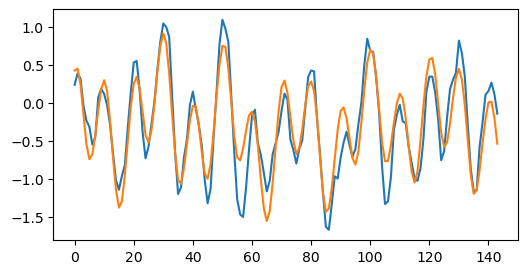

In [7]:
jdata = 9

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

### Training the uncertainty of a stationary operator

In [8]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train nominal uncertainty >>>
	epoch 1 losses: train=0.512692, valid=0.335236, test=0.366551
	validation loss decreased (inf -> 0.335236), saving model ...
	epoch 2 losses: train=0.342891, valid=0.307228, test=0.343480
	validation loss decreased (0.335236 -> 0.307228), saving model ...
	epoch 3 losses: train=0.329422, valid=0.299382, test=0.335407
	validation loss decreased (0.307228 -> 0.299382), saving model ...
	epoch 4 losses: train=0.322396, valid=0.295614, test=0.330008
	validation loss decreased (0.299382 -> 0.295614), saving model ...
	epoch 5 losses: train=0.317803, valid=0.293427, test=0.326796
	validation loss decreased (0.295614 -> 0.293427), saving model ...
	epoch 6 losses: train=0.315641, valid=0.287700, test=0.324706
	validation loss decreased (0.293427 -> 0.287700), saving model ...
	epoch 7 losses: train=0.309090, valid=0.280374, test=0.314231
	validation loss decreased (0.287700 -> 0.280374), saving model ...
	epoch 8 losses: train=0.293770, valid=0.259727, test=

In [9]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

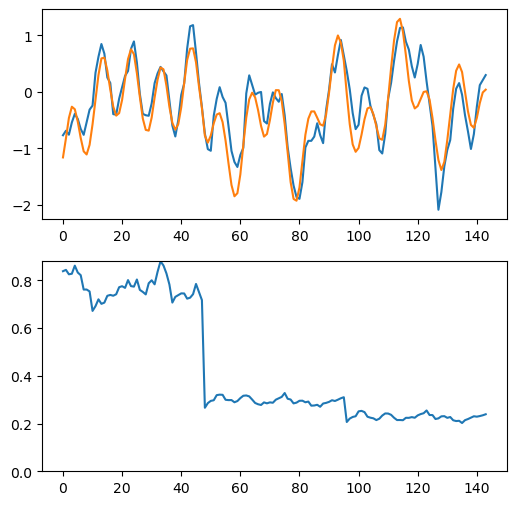

In [10]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

### Training the mean of a transient operator

In [11]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train excursion mean >>>
	epoch 1 losses: train=1.785490, valid=1.478247, test=1.384453
	validation loss decreased (inf -> 1.478247), saving model ...
	epoch 2 losses: train=1.548230, valid=1.078982, test=1.041516
	validation loss decreased (1.478247 -> 1.078982), saving model ...
	epoch 3 losses: train=1.215666, valid=0.925026, test=0.899193
	validation loss decreased (1.078982 -> 0.925026), saving model ...
	epoch 4 losses: train=0.936478, valid=0.657785, test=0.651399
	validation loss decreased (0.925026 -> 0.657785), saving model ...
	epoch 5 losses: train=0.801775, valid=0.596197, test=0.597263
	validation loss decreased (0.657785 -> 0.596197), saving model ...
	epoch 6 losses: train=0.734850, valid=0.544487, test=0.549711
	validation loss decreased (0.596197 -> 0.544487), saving model ...
	epoch 7 losses: train=0.697371, valid=0.525790, test=0.531954
	validation loss decreased (0.544487 -> 0.525790), saving model ...
	epoch 8 losses: train=0.675534, valid=0.513277, test=0.519

In [12]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

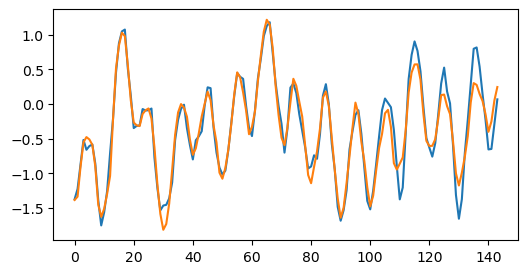

In [13]:
jdata = 21

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

### Training the uncertainty of a transient operator

In [14]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train excursion uncertainty >>>
	epoch 1 losses: train=0.333051, valid=0.028482, test=0.030742
	validation loss decreased (inf -> 0.028482), saving model ...
	epoch 2 losses: train=-0.041138, valid=-0.031680, test=-0.037193
	validation loss decreased (0.028482 -> -0.031680), saving model ...
	epoch 3 losses: train=-0.114680, valid=-0.120613, test=-0.113884
	validation loss decreased (-0.031680 -> -0.120613), saving model ...
	epoch 4 losses: train=-0.201765, valid=-0.193403, test=-0.190761
	validation loss decreased (-0.120613 -> -0.193403), saving model ...
	epoch 5 losses: train=-0.223396, valid=-0.194416, test=-0.196589
	validation loss decreased (-0.193403 -> -0.194416), saving model ...
	epoch 6 losses: train=-0.249352, valid=-0.253802, test=-0.253091
	validation loss decreased (-0.194416 -> -0.253802), saving model ...
	epoch 7 losses: train=-0.315523, valid=-0.283785, test=-0.283770
	validation loss decreased (-0.253802 -> -0.283785), saving model ...
	epoch 8 losses: train=

In [15]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

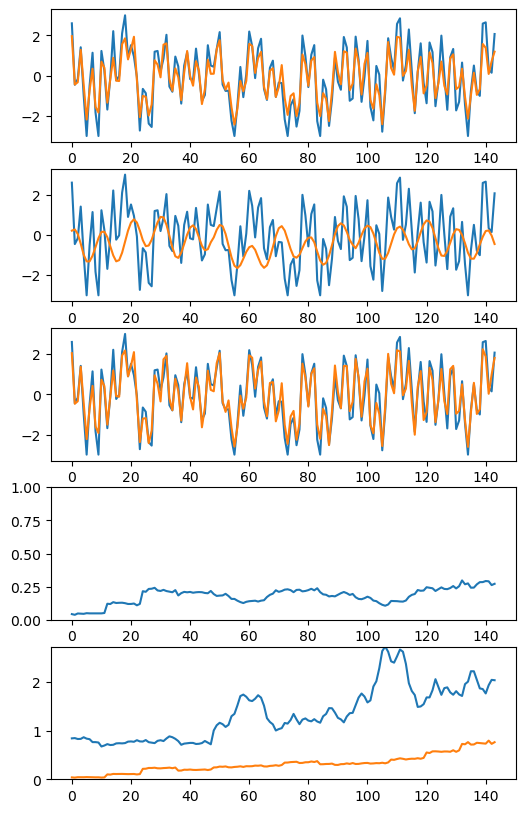

In [16]:
jdata = 30

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])
        plt.ylim((0., 1.))

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break